目标目录: /home/zchen/Code/NeUF/seg_test/Pre_traitement_echo_v2/Cropping/Patient104_J0_0
发现 .mat 文件数量: 2

[1/2] 文件: data_repos_Patient104_J0_0.mat
  变量数量: 1
  - data_repos: {'shape': (796, 1536, 220), 'dtype': 'uint8', 'ndim': 3, 'size': 268984320, 'min': 0.0, 'max': 255.0, 'mean': 8.926991235028124, 'std': 17.684106646240537}


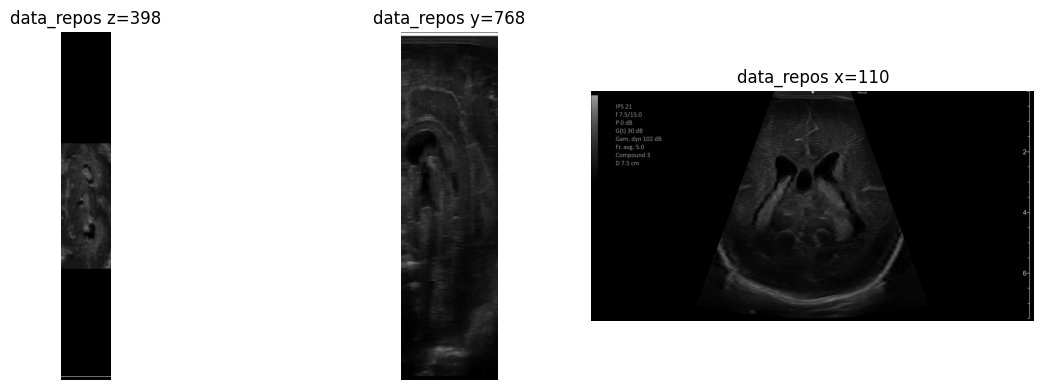

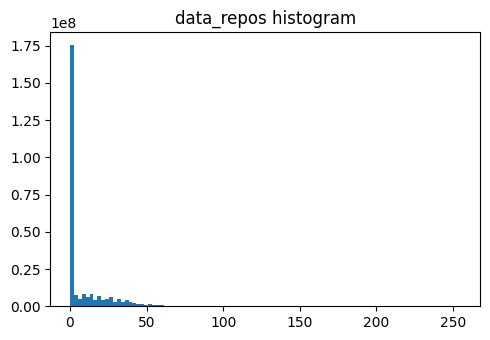


[2/2] 文件: data_repos_Patient104_J0_0_sag.mat
  变量数量: 1
  - data_sag: {'shape': (796, 1536), 'dtype': 'uint8', 'ndim': 2, 'size': 1222656, 'min': 0.0, 'max': 255.0, 'mean': 9.362663741886516, 'std': 18.104420887383093}


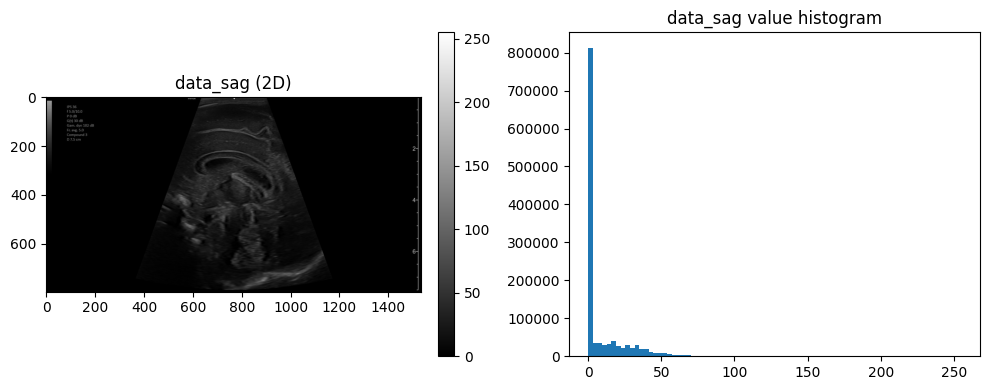


读取与可视化完成。all_summaries 字典中保存了所有文件的摘要信息。


In [1]:
import os
import glob
import warnings

import numpy as np
import matplotlib.pyplot as plt

# 优先用 scipy 读取常见 MAT；若是 v7.3 再回退 h5py
from scipy.io import loadmat

try:
    import h5py
except Exception:
    h5py = None

MAT_DIR = "/home/zchen/Code/NeUF/seg_test/Pre_traitement_echo_v2/Cropping/Patient104_J0_0"


def _safe_numeric(a):
    arr = np.asarray(a)
    return np.issubdtype(arr.dtype, np.number)


def _describe_array(arr, max_unique=12):
    arr = np.asarray(arr)
    info = {
        "shape": arr.shape,
        "dtype": str(arr.dtype),
        "ndim": arr.ndim,
        "size": arr.size,
    }

    if arr.size == 0:
        info["empty"] = True
        return info

    if _safe_numeric(arr):
        finite = np.isfinite(arr)
        if finite.any():
            vals = arr[finite]
            info.update(
                {
                    "min": float(np.min(vals)),
                    "max": float(np.max(vals)),
                    "mean": float(np.mean(vals)),
                    "std": float(np.std(vals)),
                }
            )
        else:
            info["all_non_finite"] = True

        # 小数组给出唯一值预览
        if arr.size <= 5_000:
            uniq = np.unique(arr)
            if uniq.size <= max_unique:
                info["unique_values"] = uniq.tolist()
            else:
                info["unique_count"] = int(uniq.size)
    else:
        info["preview"] = str(arr.flat[0]) if arr.size else ""

    return info


def _plot_numeric(name, arr):
    arr = np.asarray(arr)
    if arr.size == 0 or not _safe_numeric(arr):
        return

    # 统一转 float 方便显示
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a = np.array(arr, dtype=np.float32)

    if a.ndim == 0:
        print(f"    [plot] {name}: scalar = {a.item()}")
        return

    if a.ndim == 1:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
        axes[0].plot(a)
        axes[0].set_title(f"{name} (1D line)")
        axes[0].set_xlabel("index")
        axes[0].set_ylabel("value")

        axes[1].hist(a[np.isfinite(a)], bins=50)
        axes[1].set_title(f"{name} histogram")
        plt.tight_layout()
        plt.show()
        return

    if a.ndim == 2:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        im = axes[0].imshow(a, cmap="gray")
        axes[0].set_title(f"{name} (2D)")
        plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

        axes[1].hist(a[np.isfinite(a)].ravel(), bins=80)
        axes[1].set_title(f"{name} value histogram")
        plt.tight_layout()
        plt.show()
        return

    if a.ndim == 3:
        z, y, x = a.shape
        cz, cy, cx = z // 2, y // 2, x // 2

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(a[cz, :, :], cmap="gray")
        axes[0].set_title(f"{name} z={cz}")
        axes[1].imshow(a[:, cy, :], cmap="gray")
        axes[1].set_title(f"{name} y={cy}")
        axes[2].imshow(a[:, :, cx], cmap="gray")
        axes[2].set_title(f"{name} x={cx}")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(5, 3.5))
        plt.hist(a[np.isfinite(a)].ravel(), bins=100)
        plt.title(f"{name} histogram")
        plt.tight_layout()
        plt.show()
        return

    # 4D+：尝试展示第一个切片，并画总体直方图
    head = a
    while head.ndim > 2:
        head = head[0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    im = axes[0].imshow(head, cmap="gray")
    axes[0].set_title(f"{name} first-slice preview")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    axes[1].hist(a[np.isfinite(a)].ravel(), bins=100)
    axes[1].set_title(f"{name} full histogram")
    plt.tight_layout()
    plt.show()


def _load_mat(path):
    # 先用 scipy，失败时若存在 h5py 再尝试 v7.3 读取
    try:
        d = loadmat(path)
        # 去掉 MATLAB 元信息字段
        return {k: v for k, v in d.items() if not k.startswith("__")}
    except NotImplementedError:
        if h5py is None:
            raise RuntimeError(
                f"{path} 可能是 MATLAB v7.3，但当前环境没有 h5py，无法读取。"
            )

        out = {}
        with h5py.File(path, "r") as f:
            for k in f.keys():
                try:
                    out[k] = np.array(f[k])
                except Exception:
                    out[k] = f[k]
        return out


mat_files = sorted(glob.glob(os.path.join(MAT_DIR, "*.mat")))
print(f"目标目录: {MAT_DIR}")
print(f"发现 .mat 文件数量: {len(mat_files)}")

if not mat_files:
    raise FileNotFoundError("该目录下没有找到 .mat 文件。")

all_summaries = {}

for i, mat_path in enumerate(mat_files, 1):
    print("\n" + "=" * 100)
    print(f"[{i}/{len(mat_files)}] 文件: {os.path.basename(mat_path)}")

    data = _load_mat(mat_path)
    all_summaries[mat_path] = {}

    print(f"  变量数量: {len(data)}")
    if not data:
        print("  (无可用变量)")
        continue

    for name, val in data.items():
        try:
            desc = _describe_array(val)
            all_summaries[mat_path][name] = desc
            print(f"  - {name}: {desc}")

            # 尽量可视化：仅对数值数组做图
            _plot_numeric(name, val)
        except Exception as e:
            print(f"  - {name}: [无法解析/可视化] {type(e).__name__}: {e}")

print("\n读取与可视化完成。all_summaries 字典中保存了所有文件的摘要信息。")